# Parameter calibration based on polarization test data — 0D model

This notebook calibrates the undetermined physical parameters of the Pukrushpan-style 0D PEMFC model (`PEMFC_0D`) by fitting the simulated cell voltage to experimental measurements across the same 12 operating conditions (temperature, pressure, humidity) used for the 1D static and dynamic notebooks.

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
from copy import deepcopy
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dualscale import PEMFC_0D
from model.coefficients import *
from config.initialize import *

## Voltage model: 1D (Raphael) vs. 0D (hybrid Raphael / Pukrushpan)

The 0D voltage is a **hybrid** of Raphael's Butler-Volmer cathode overpotential and Pukrushpan's empirical concentration-loss regression. This lets the calibration handles `OCV`, `i0_c_ref`, `kappa_c` move the activation/Nernst part while a separate `i_max` / `c2` / `c3` triple shapes the rollover near limiting current. `Hcl`, `Vol_a` and `Vol_c` join the list as indirect handles via the cell water and species balances.

| Aspect | **1D model** (`PEMFC`, `PEMFC_dyn`) | **0D model** (`PEMFC_0D`) |
|---|---|---|
| Reference | Raphael Gass's thesis, eqs. 1.64–1.79 / 2.49–2.59 | Raphael's eta_c (eq. 1.67) + Pukrushpan v_conc (eq. 3.21) |
| Cell voltage | `Ucell = Ueq − η_c − i·(Rp + Re)` | `Ucell = OCV − eta_c − v_ohm − v_conc` |
| Open-circuit term | **Ueq** — Nernst with the **catalyst-layer** concentrations `C_H2_acl`, `C_O2_ccl` resolved by the 1D mesh | **OCV** — a single calibrated number that absorbs the Nernst part plus any parasitic / crossover offset |
| Activation loss | **η_c** — Butler-Volmer with calibrated `i0_c_ref`, `α_c`, `κ_c`, `E_act`, divided by `f_drop` when liquid water builds up | **eta_c** — same Butler-Volmer formula as 1D, evaluated on the lumped chamber `C_O2_c` and with `f_drop = 1` (no liquid-water state in 0D) |
| Concentration loss | Emerges *physically* from the spatial gradient of `C_O2` through the GDL+CL (already inside η_c via `C_O2_ccl < C_O2_cgc`) | **v_conc = i·(c_2·i/i_max)^{c_3}** — Pukrushpan's empirical rollover, with `i_max`, `c_2`, `c_3` exposed as calibration handles (defaults 2.2 A/cm² / 1.0 / 2.0) |
| Flooding penalty | **f_drop(s_cgdl, P)** divides η_c by ≤ 1 to inflate the overpotential when `s_cgdl` exceeds `s_lim` | **None** — folded into the empirical `v_conc` rollover |
| Protonic resistance | **Rp = Σ R_mem(i) + R_ccl + R_acl** summed over the `n_mem` membrane nodes and both catalyst layers, each with Springer conductivity (b2 = 1268, piecewise at λ = 1) | **R_ohm = Hmem / σ_m** with a *single* lumped membrane and Pukrushpan's modified Springer (`b1 = 0.005139·λ_eff − 0.00326`, **b2 = 350**, λ_eff = max(λ, 1) to keep b1 ≥ 0) |
| Electronic resistance | Calibrated `Re` | Same — calibrated `Re`, contributes through `v_ohm = i·(Rohm + Re)` |
| Membrane water dynamics | Per-node `λ_acl`, `λ_mem(i)`, `λ_ccl` from Springer sorption / EOD / back-diffusion with `Hcl` setting the per-CL sorption rate | Single lumped `λ_mem` from `dλ/dt = M_eq/(ρ_mem·ε_mc) · (S_sorp_a + S_sorp_c)` — Hcl appears in `γ_sorp` and so still drives the equilibrium λ_mem |
| Cell-chamber volumes | `Aact · H_layer` per spatial node, no calibration knob | **`Vol_a`, `Vol_c`** override the geometric default `Aact · (Hgc + ε_gdl·Hgdl + ε_cl·Hcl)`; they set how fast `C_O2_c` responds to the in/out flows and reaction consumption, and therefore the steady-state `C_O2_c` that feeds `eta_c` |
| Calibration handles | `OCV`, `i0_c_ref`, `κ_c`, `α_c`, `τ`, `Re`, `ε_mc`, `ε_gdl`, `ε_c`, `ε_cl`, `a_slim`, `b_slim`, `a_switch`, `Hcl`, `Hgdl`, … | **`OCV`, `i0_c_ref`, `κ_c`, `Re`, `i_max`, `c_2`, `c_3`, `Hcl`, `Vol_a`, `Vol_c`** — `Hmem` is held fixed at the geometric 1.2·10⁻⁵ m, and `λ_mem` is solved dynamically from the cell water balance. |

**What changed since the previous version**: Pukrushpan's `v_0 + v_a·(1 − e^{−c_1·i})` activation regression has been replaced with Raphael's `eta_c` so `OCV`, `i0_c_ref`, `κ_c` are now live handles. Pukrushpan's `v_conc` is kept but its three coefficients are now `params['i_max']`, `params['c2']`, `params['c3']` instead of hard-coded values, so the rollover near limiting current can be tuned per stack. `Hcl` is also calibrated because it enters `γ_sorp` and therefore the steady-state `λ_mem` that sets the membrane conductivity in `v_ohm`. Finally, `Vol_a` and `Vol_c` override the geometric default `Aact·(Hgc + ε_gdl·Hgdl + ε_cl·Hcl)`, which lets the optimizer adjust the steady-state `C_O2_c` (and thus `eta_c`) without exposing the underlying `Hgc`, `Hgdl`, `ε_gdl`, `ε_cl` individually.

## Calibration setup

### Simulation setup
This step determines the accuracy and efficiency of the optimizer. Increasing the current point may increase the accuracy but definitely reduce the efficiency.

In [3]:
I_tested   = [10, 20, 30, 35, 40, 45, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5, 1.4e5, 1.5e5]
TFC_tested = [50, 60, 70]

# The Polar_curves.xlsx file holds STACK voltages (22 cells in series) and
# stack-level HFR, so the experimental data must be scaled per cell. The
# ``n_cell`` constant in coefficients.py is 1 (number of cells in the SIMULATED
# stack), not the number of cells in the experiment.
N_CELL_EXP = 22

### Experimental data import

In [4]:
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
polardata_exp = {sname: pd.read_excel(exp_pola_data, sheet_name=sname) for sname in exp_pola_data.sheet_names}

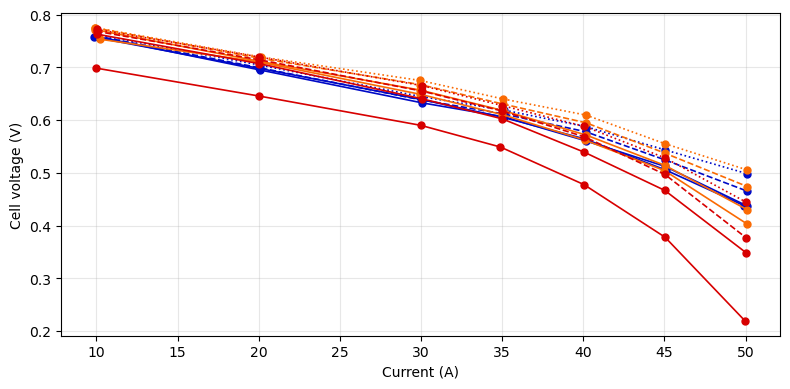

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in polardata_exp.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / N_CELL_EXP
    idx_extracted = [np.argmin((i_test - i_values) ** 2) for i_test in I_tested]
    plot_condition(ax, i_values[idx_extracted], v_values[idx_extracted], name, linewidth=1.2, markersize=5)
ax.set_xlabel("Current (A)"); ax.set_ylabel("Cell voltage (V)"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Setup the simulation for all wanted conditions

In [6]:
def polartest_sim(params_trial, op_trial, cond_filter=None, lenient=False):
    """Run the 0D model across every (RHC, P, T) condition for which we have
    experimental data and return ``{cond_key: [Ucell at I_tested]}``.
    """
    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des / 1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in polardata_exp:
                    continue
                if cond_filter is not None and not cond_filter(T_des, P_des, RHC):
                    continue
                op = dict(op_trial)
                op["Phi_c_des"] = RHC / 100
                op["Pa_des"]    = P_des
                op["Pc_des"]    = P_des
                op["Tfc"]       = T_des + 273.15

                Ucell_test = []
                cond_failed = False
                for I_LOAD in I_tested:
                    i_density = I_LOAD / params_trial["Aact"]
                    op["current_density"] = lambda t, _i=i_density: _i
                    try:
                        model = PEMFC_0D(params_trial, op)
                        y0 = model.default_initial_state(params_trial, op)
                        info = model.solve(t_span=(0, 60), y0=y0, method="BDF",
                                           max_step=0.1, verbose=False, sparsity=False,
                                           atol=1e-8, rtol=1e-6)
                        sol = info["sol"]
                        if sol is None or not sol.success:
                            cond_failed = True
                            break
                        model._recovery(sol)
                        u = model.echem_traj["Ucell"][-1]
                        if not math.isfinite(u):
                            cond_failed = True
                            break
                        Ucell_test.append(u)
                    except Exception:
                        cond_failed = True
                        break

                if cond_failed:
                    if lenient:
                        continue   # skip this cond, keep sweeping
                    return False   # strict: abort the whole sweep
                result[cond_key] = Ucell_test
    return result

In [7]:
def _experimental_ucell(cond_key):
    """Experimental per-cell voltage at every I_tested for one condition."""
    df = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / N_CELL_EXP
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return v_exp[idx]


def make_objective(cond_filter):
    """Return an optuna objective that fits only the conditions selected by
    ``cond_filter`` -- so a single objective function can be reused across
    the calibration scenarios.

    The 0D voltage is the hybrid ``OCV - eta_c - v_ohm - v_conc`` (see the
    "Voltage model: 1D vs 0D" cell above). The active calibration handles are
    therefore:

      - OCV, i0_c_ref, kappa_c    -- enter through eta_c (Raphael's cathode
                                     Butler-Volmer)
      - Re                         -- electronic contribution to v_ohm
      - i_max, c2, c3              -- shape the empirical v_conc rollover
      - Hcl                        -- catalyst-layer thickness; enters the
                                     sorption-rate coefficient gamma_sorp,
                                     which steers lambda_mem and therefore
                                     the membrane Springer conductivity in
                                     v_ohm
      - Vol_a, Vol_c               -- lumped anode / cathode chamber volumes;
                                     they set the time constant of the
                                     concentration response and the
                                     steady-state C_O2_c that feeds eta_c

    Hmem is held at the geometric value 1.2e-5 m (no calibration), as is the
    Springer ohmic regression (b2 = 350, b1 floor at lambda = 1).
    """
    def objective(trial):
        params_trial = deepcopy(parameters)
        # Use a coarse Pt PSD grid for calibration speed -- PSD detail doesn't
        # affect the steady-state polar curve.
        params_trial["n_group_pt"] = 10
        op_trial = deepcopy(operating_inputs)

        # ---- eta_c handles (Raphael) ----
        params_trial["OCV"]      = trial.suggest_float("OCV",      0.90, 1.00, log=True)
        params_trial["i0_c_ref"] = trial.suggest_float("i0_c_ref", 1e-2, 10,   log=True)
        params_trial["kappa_c"]  = trial.suggest_float("kappa_c",  1,    10,   log=True)
        # ---- electronic resistance ----
        params_trial["Re"]       = trial.suggest_float("Re",       1e-7, 1e-5, log=True)
        # ---- Pukrushpan v_conc handles ----
        params_trial["i_max"]    = trial.suggest_float("i_max",    1.0,  5.0)   # A.cm-2
        params_trial["c2"]       = trial.suggest_float("c2",       0.1,  5.0, log=True)
        params_trial["c3"]       = trial.suggest_float("c3",       1.0,  3.0)
        # ---- membrane water sorption (gamma_sorp depends on Hcl) ----
        params_trial["Hcl"]      = trial.suggest_float("Hcl",      1e-5, 2e-5, log=True)
        # ---- lumped chamber volumes (override the geometric default) ----
        params_trial["Vol_a"]    = trial.suggest_float("Vol_a",    1e-7, 1e-5, log=True)
        params_trial["Vol_c"]    = trial.suggest_float("Vol_c",    1e-7, 1e-5, log=True)

        try:
            sim = polartest_sim(params_trial, op_trial, cond_filter=cond_filter)
        except Exception:
            return 100.0
        if sim is False or not sim:
            return 100.0

        error_sum = 0.0
        for cond_key, ucell_sim in sim.items():
            ucell_exp = _experimental_ucell(cond_key)
            error_sum += float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))
        return error_sum
    return objective

## Calibration scenarios
Compare the calibration result obtained when fitting the model against different subsets of the experimental polarization data.

In [8]:
SINGLE_T   = 60       # degrees C
SINGLE_P   = 1.4e5    # Pa
SINGLE_RHC = 50       # %
TWO_HUM_T  = 50       # degrees C
TWO_HUM_P  = 1.3e5    # Pa
FIXED_P    = 1.3e5    # Pa
FIXED_T    = 60       # degrees C

scenarios = {
    "one_condition":      {
        "label":  f"One condition (T={SINGLE_T}, P={SINGLE_P/1e5:.1f} bar, RHC={SINGLE_RHC})",
        "filter": lambda T, P, RHC: (T == SINGLE_T) and (P == SINGLE_P) and (RHC == SINGLE_RHC),
    },
    "two_humidification": {
        "label":  f"Two humidifications (P={TWO_HUM_P/1e5:.1f} bar, T={TWO_HUM_T}, RHC in {{0, 50}})",
        "filter": lambda T, P, RHC: (T == TWO_HUM_T) and (P == TWO_HUM_P) and (RHC in (0, 50)),
    },
    "fixed_pressure":     {
        "label":  f"Fixed pressure (P={FIXED_P/1e5:.1f} bar, all T, all RHC)",
        "filter": lambda T, P, RHC: P == FIXED_P,
    },
    "fixed_temperature":  {
        "label":  f"Fixed temperature (T={FIXED_T}, all P, all RHC)",
        "filter": lambda T, P, RHC: T == FIXED_T,
    },
    "all_data":           {
        "label":  "All conditions",
        "filter": lambda T, P, RHC: True,
    },
}


def conditions_in_scenario(filter_fn):
    keys = []
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                exp_data = globals().get("polardata_exp") or globals().get("hfrdata_exp") or {}
                if cond_key in exp_data and filter_fn(T_des, P_des, RHC):
                    keys.append(cond_key)
    return keys


for name, info in scenarios.items():
    matches = conditions_in_scenario(info["filter"])
    print(f"  {name:20s}  {len(matches):2d} conditions  -> {matches}")

  one_condition          1 conditions  -> ['T60_P400_HRC50']
  two_humidification     2 conditions  -> ['T50_P300_HRC0', 'T50_P300_HRC50']
  fixed_pressure         6 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
  fixed_temperature      4 conditions  -> ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
  all_data              12 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50', 'T50_P400_HRC50', 'T60_P400_HRC50', 'T70_P400_HRC50', 'T50_P500_HRC50', 'T60_P500_HRC50', 'T70_P500_HRC50']


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

PER_SCENARIO_TIMEOUT = 300     # seconds
PER_SCENARIO_TRIALS  = 15000
N_JOBS               = 8 

results = {}
for name, info in scenarios.items():
    print(f"\n=== Calibrating scenario: {name} ===")
    print(f"    {info['label']}")
    print(f"    conditions used: {conditions_in_scenario(info['filter'])}")
    study = optuna.create_study(direction="minimize")
    study.optimize(
        make_objective(info["filter"]),
        n_trials=PER_SCENARIO_TRIALS,
        timeout=PER_SCENARIO_TIMEOUT,
        n_jobs=N_JOBS,
        show_progress_bar=False,
    )

    # Re-run polartest_sim with the best params over ALL conditions so we can
    # later check how well each scenario generalises. Use lenient=True here so
    # that a single bad condition does not wipe the calibrated condition off
    # the fit plot.
    params_best = deepcopy(parameters)
    params_best["n_group_pt"] = 10
    op_best     = deepcopy(operating_inputs)
    params_best.update(study.best_params)
    sim_all     = polartest_sim(params_best, op_best, cond_filter=None, lenient=True)

    results[name] = {
        "label":           info["label"],
        "calibrated_keys": conditions_in_scenario(info["filter"]),
        "best_params":     study.best_params,
        "best_value":      study.best_value,
        "sim_all":         sim_all,
    }
    print(f"    best objective on the calibrated subset: {study.best_value:.4f}")
    n_ok = len(sim_all); n_total = len(polardata_exp)
    print(f"    sim_all covered {n_ok}/{n_total} conditions")


=== Calibrating scenario: one_condition ===
    One condition (T=60, P=1.4 bar, RHC=50)
    conditions used: ['T60_P400_HRC50']
    best objective on the calibrated subset: 0.0026
    sim_all covered 12/12 conditions

=== Calibrating scenario: two_humidification ===
    Two humidifications (P=1.3 bar, T=50, RHC in {0, 50})
    conditions used: ['T50_P300_HRC0', 'T50_P300_HRC50']
    best objective on the calibrated subset: 0.0448
    sim_all covered 12/12 conditions

=== Calibrating scenario: fixed_pressure ===
    Fixed pressure (P=1.3 bar, all T, all RHC)
    conditions used: ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']


## Best parameters side-by-side
How much do the calibrated parameters change as you broaden the training set? Big swings indicate the parameter is poorly constrained by the partial dataset.

In [ ]:
param_df = pd.DataFrame({name: info["best_params"] for name, info in results.items()})
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))

          one_condition  two_humidification  fixed_pressure  fixed_temperature  all_data
OCV              0.9089              0.9402           0.914             0.9525    0.9822
i0_c_ref          1.569              0.3537           1.994            0.05841   0.03634
kappa_c           1.466               1.929           1.743              4.251     2.162
Re            6.903e-06           9.048e-06       1.083e-06           9.28e-06 8.194e-07
i_max             3.007               4.964           4.721              3.723     2.866
c2               0.4083              0.9369          0.9744             0.8941    0.6939
c3                1.197               2.547           1.193              1.744     1.926
Hcl           1.156e-05           1.993e-05       1.373e-05          1.447e-05 1.366e-05


## Compare best-fit polarization curves across scenarios
`plot_scenario_fit(name)` produces two figures per scenario: the fit on the conditions used during calibration, then the fit on every experimental condition.

In [ ]:
def plot_scenario_fit(name):
    """For one calibration scenario, show two figures: the fit on the
    conditions used in the optimisation, then the fit on all conditions.
    Blue solid markers = experiment, red dotted squares = simulation.
    """
    info = results[name]
    cal_set = set(info["calibrated_keys"])

    panels_to_show = [
        ("USED for calibration", info["calibrated_keys"]),
        ("ALL conditions",       list(polardata_exp.keys())),
    ]
    for title_suffix, keys in panels_to_show:
        n = len(keys)
        if n == 0:
            print(f"({name}: no conditions for '{title_suffix}')")
            continue
        ncols = min(4, max(1, n))
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, cond_key in zip(axes.flatten(), keys):
            ucell_exp = _experimental_ucell(cond_key)
            ucell_sim = info["sim_all"].get(cond_key)
            ax.plot(I_tested, ucell_exp, "o-", color="tab:blue",
                    linewidth=1.4, label="experiment")
            if ucell_sim is not None:
                ax.plot(I_tested, ucell_sim, "s:", color="tab:red",
                        linewidth=1.2, label="simulated")
            in_cal = cond_key in cal_set
            tag = "[CAL] " if in_cal else ""
            ax.set_title(f"{tag}{cond_key}", fontsize=8,
                         color="tab:green" if in_cal else "black")
            ax.grid(True, alpha=0.3)
        for ax in axes.flatten()[n:]:
            ax.set_visible(False)
        axes.flatten()[0].legend(fontsize=8, loc="best")
        fig.suptitle(f"{info['label']}  --  {title_suffix}\n"
                     f"objective on calibrated subset = {info['best_value']:.4f}",
                     fontsize=10)
        fig.tight_layout()
        plt.show()

### Scenario: `one_condition`

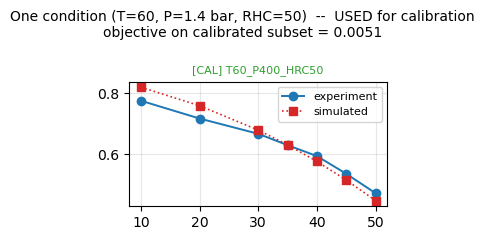

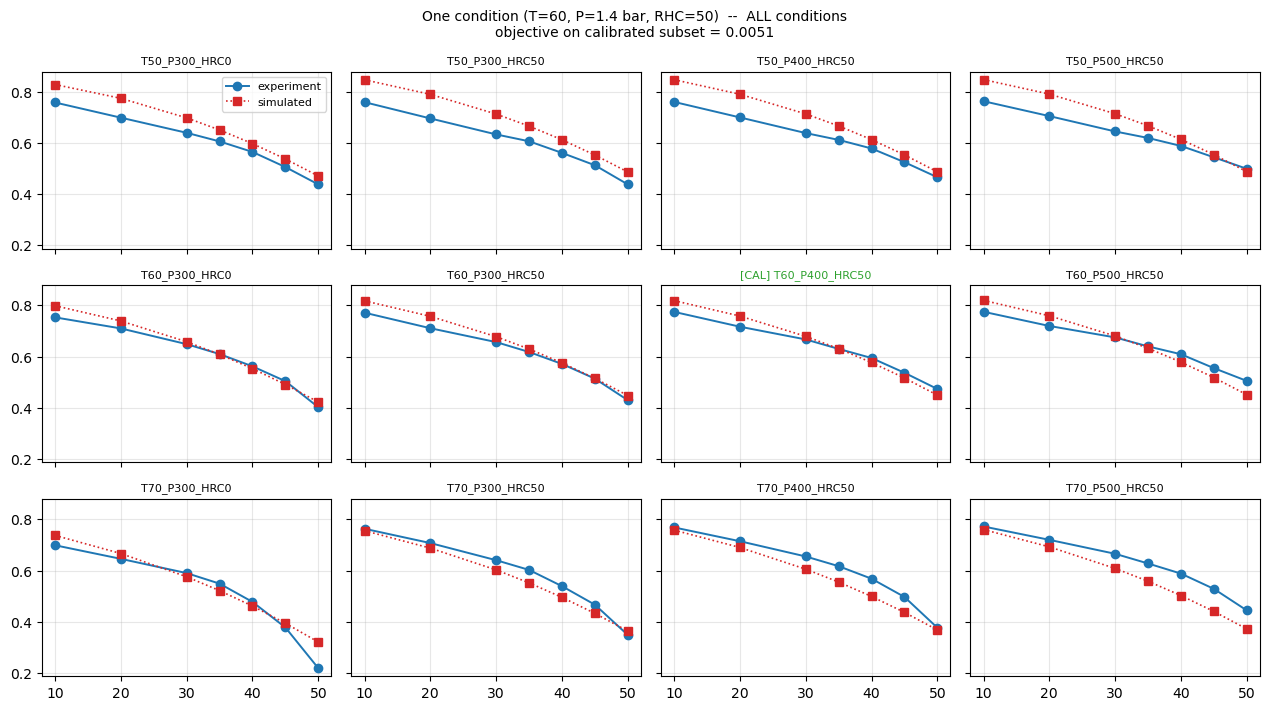

In [ ]:
plot_scenario_fit("one_condition")

### Scenario: `two_humidification`

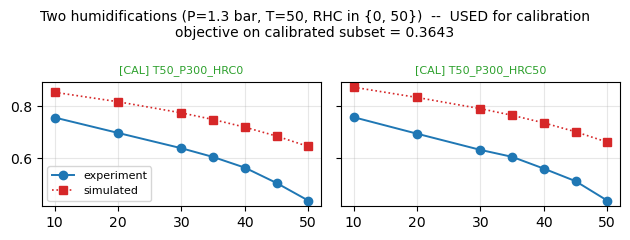

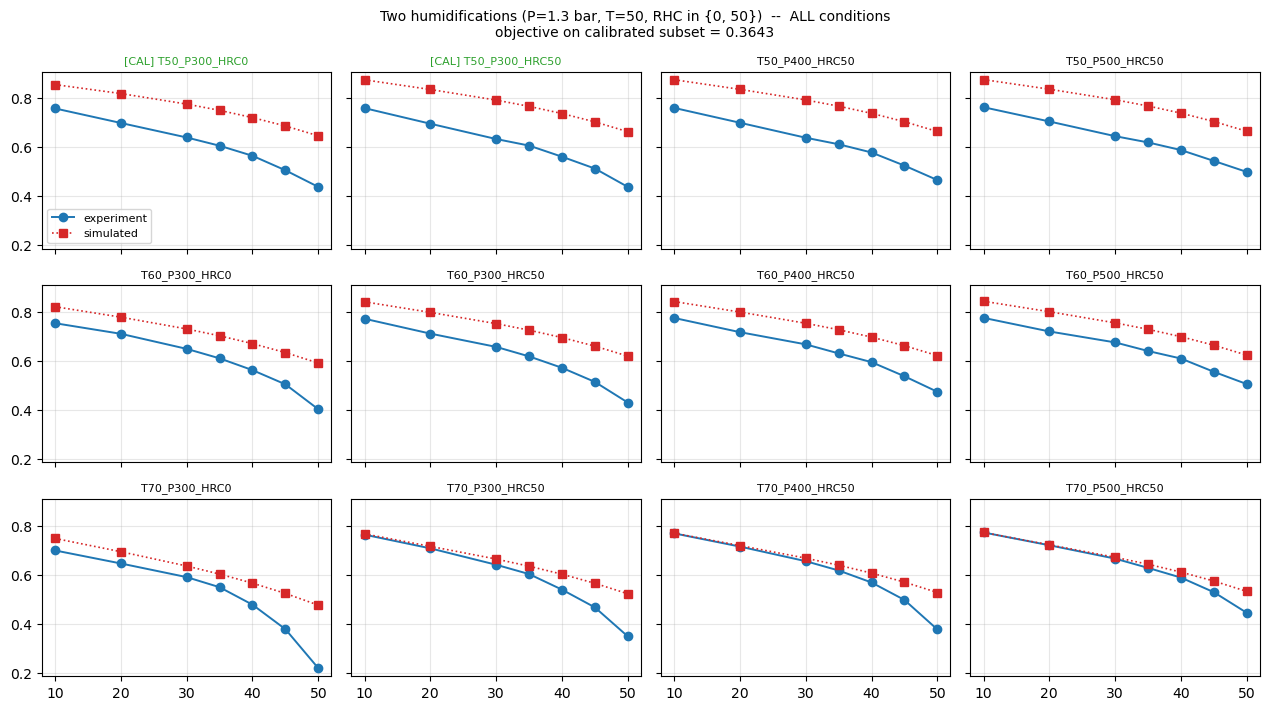

In [ ]:
plot_scenario_fit("two_humidification")

### Scenario: `fixed_pressure`

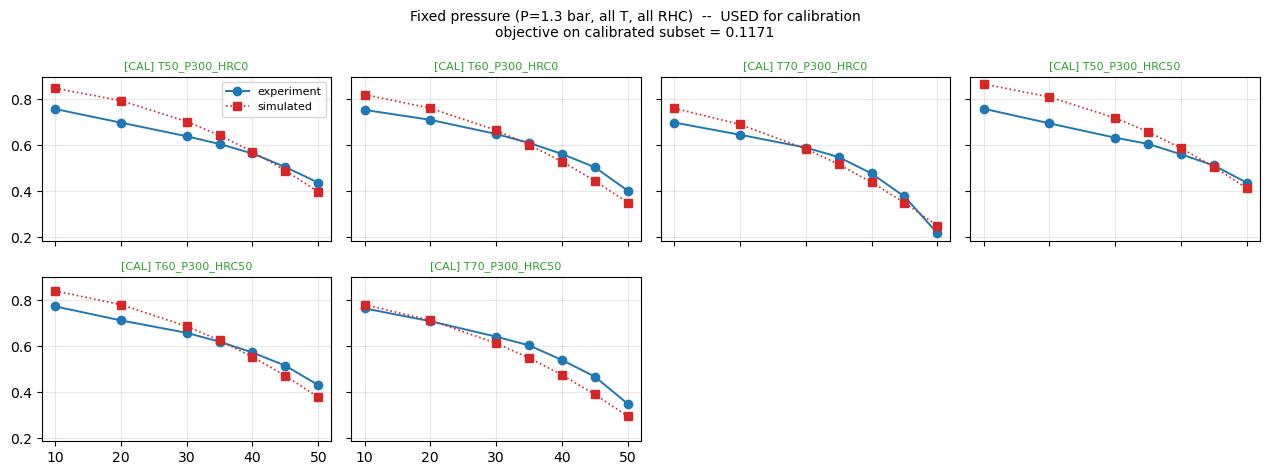

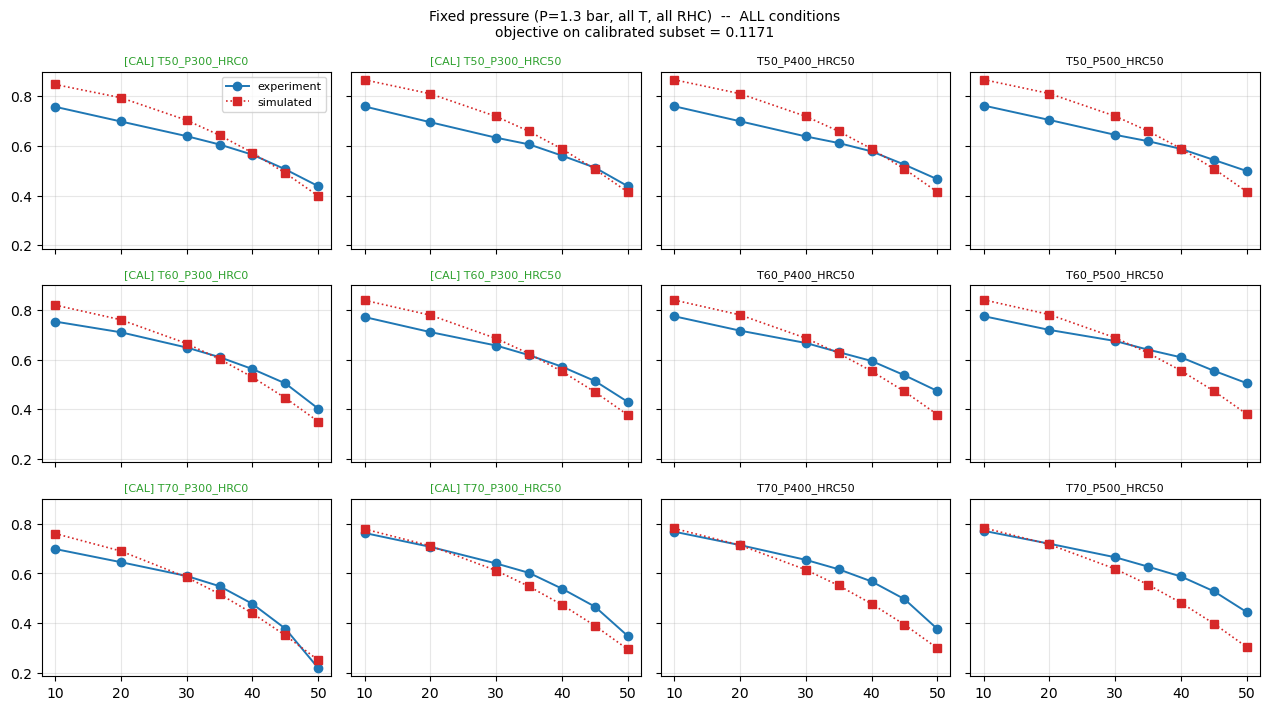

In [ ]:
plot_scenario_fit("fixed_pressure")

### Scenario: `fixed_temperature`

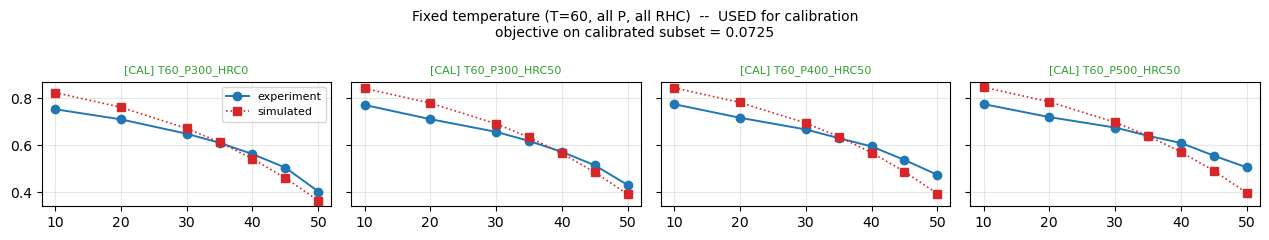

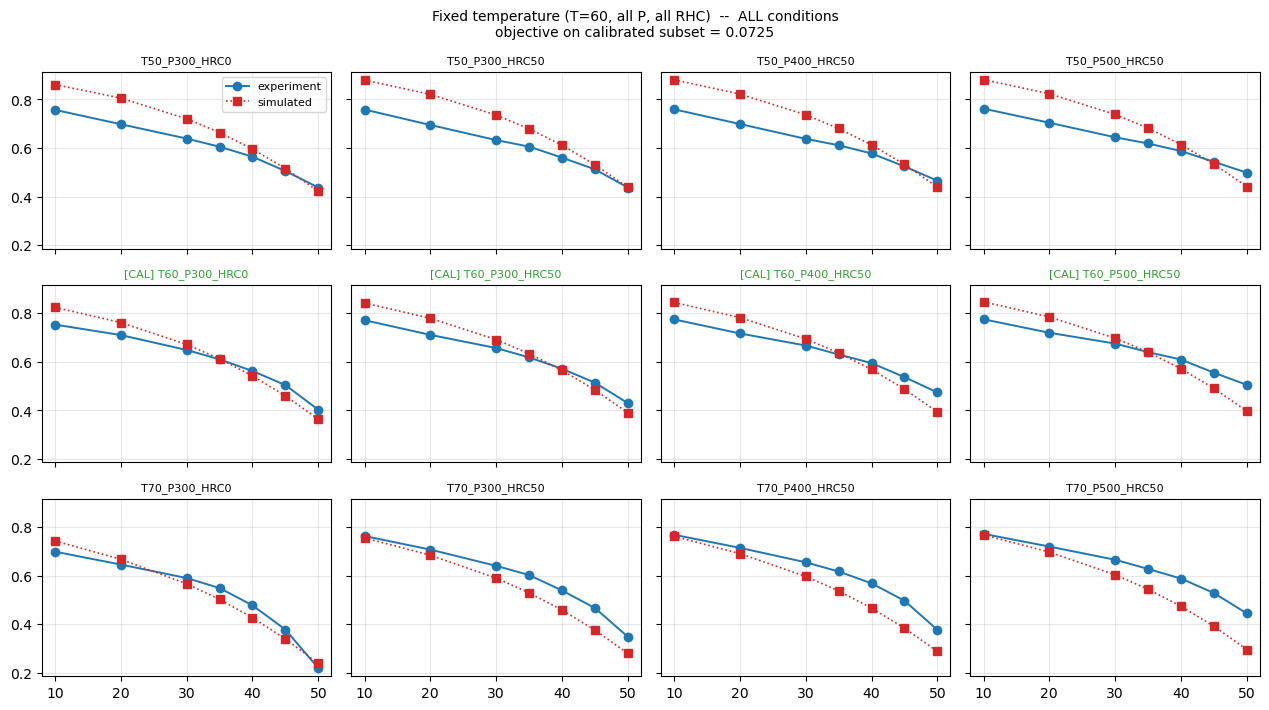

In [ ]:
plot_scenario_fit("fixed_temperature")

### Scenario: `all_data`

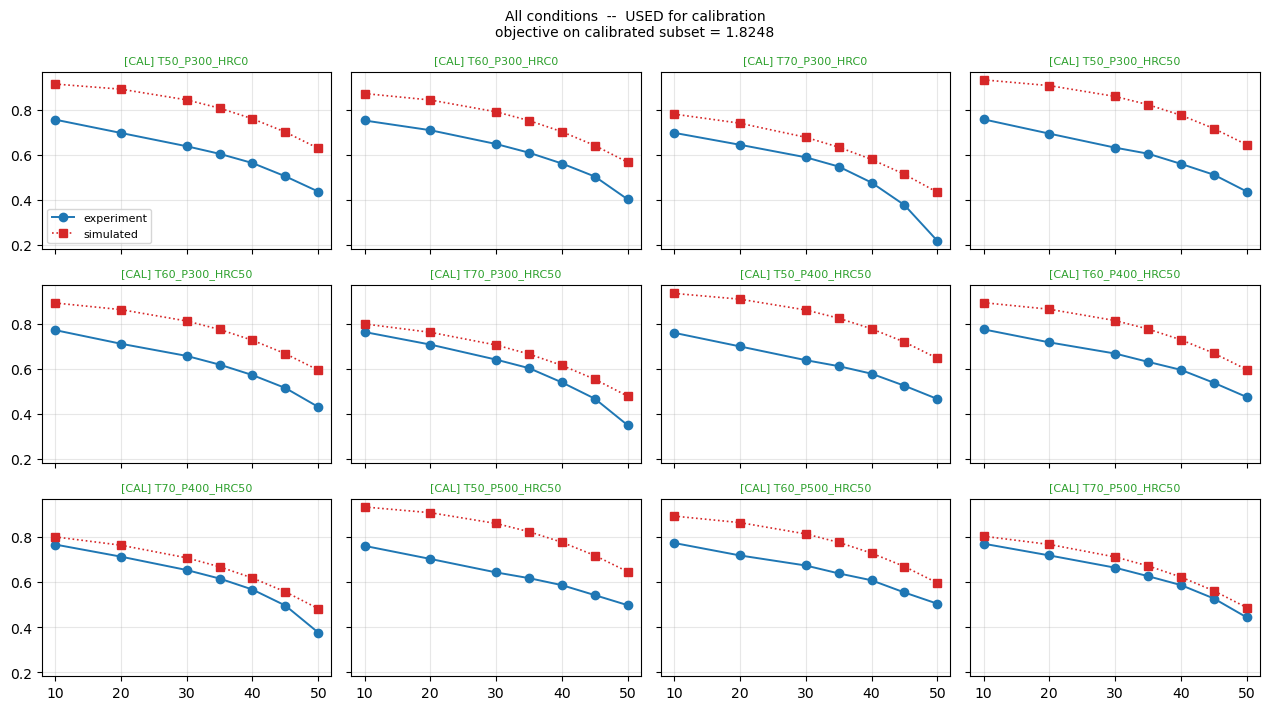

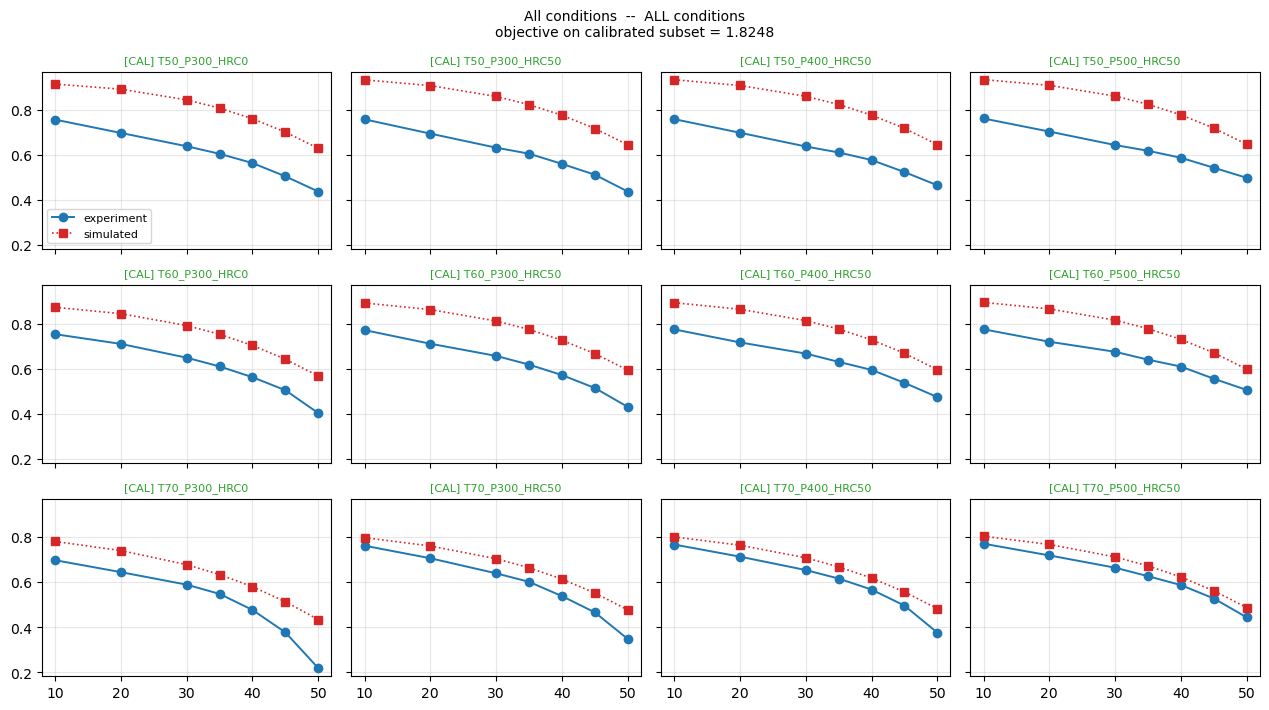

In [ ]:
plot_scenario_fit("all_data")

## Residual heatmap
Each row is a calibration scenario, each column an operating condition; the value is the sum of squared errors over the tested current points. Bright (low residual) on a column the scenario did NOT use during calibration tells you the scenario generalised; dark (large residual) tells you it did not.

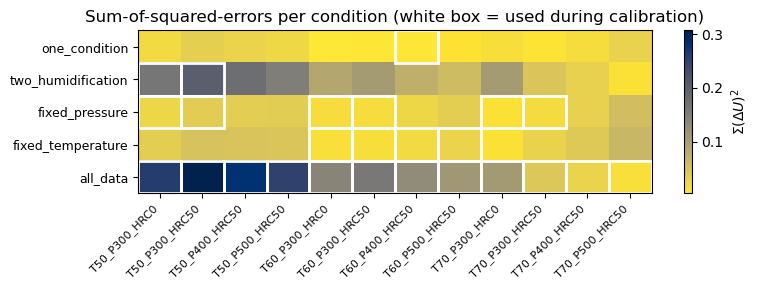

In [ ]:
all_cond_keys = list(polardata_exp.keys())
n_scen = len(results)
residual_matrix = np.full((n_scen, len(all_cond_keys)), np.nan)
for i_scen, (name, info) in enumerate(results.items()):
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key not in info["sim_all"]:
            continue
        ucell_sim = np.array(info["sim_all"][cond_key])
        ucell_exp = _experimental_ucell(cond_key)
        residual_matrix[i_scen, i_cond] = float(np.sum((ucell_sim - ucell_exp) ** 2))

fig, ax = plt.subplots(figsize=(max(8, len(all_cond_keys) * 0.5), 0.5 + 0.5 * n_scen))
im = ax.imshow(residual_matrix, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(n_scen)); ax.set_yticklabels(list(results.keys()), fontsize=9)
ax.set_xticks(range(len(all_cond_keys)))
ax.set_xticklabels(all_cond_keys, rotation=45, ha="right", fontsize=8)
for i_scen, (name, info) in enumerate(results.items()):
    cal_set = set(info["calibrated_keys"])
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key in cal_set:
            ax.add_patch(plt.Rectangle((i_cond - 0.5, i_scen - 0.5), 1, 1,
                                       fill=False, edgecolor="white", linewidth=2))
ax.set_title("Sum-of-squared-errors per condition (white box = used during calibration)")
fig.colorbar(im, ax=ax, label=r"$\Sigma(\Delta U)^2$")
plt.tight_layout(); plt.show()